**Lab 3: Spectral Representation**

The goal of this lab is to gain familiarity with the spectral representations of signals, specially the spectrograms.

In [1]:
import os
import numpy as np
import librosa
import IPython.display as ipd
import matplotlib.pyplot as plt

from util import load_audio, plot_signals, plot_spectrogram, plot_mean_spectrogram, plot_spectrum_at

First upload your reference signal and plot the first seconds of it.

In [ ]:
# Write the code here
ref, fs = load_audio('./edited_audiowav.wav')
t_start = 0
t_end = 0.4
plot_signals(ref, fs, t_start, t_end)

# **Exercises**

**1. Spectrograms**

A spectrogram is obtained by estimating the frequency content in short sections of the signal. The magnitude of the spectrum over individual sections is plotted as intensity or color on a two-dimensional plot versus frequency and time. The length of each section, or window length, determines the frequency resolution. Longer windows give good frequency resolution but fail to
track frequency changes well. Shorter windows have poor frequency resolution, but good tracking.

In Python the function `spectrogram` from the `scipy.signal` package will
compute the spectrogram. A common call to the function is defined as follows. No need to understand the meaning of each parameter at this stage. Note that we provide the `plot_spectrogram` function to plot the spectrogram.

We can plot the spectrum (one slice of the spectrogram) of the signal at an specific time using the `plot_spectrum_at` function. For instance, we can see the spectrum of the signal at the 0.5 seconds:

In [ ]:
plot_spectrum_at(ff, tt, S, 0.5)

1.1. Calculate and plot the spectrogram of your reference signal. Use `plt.ylim` to select the limits of the y axis in order to zoom in the frequency region of interest. For instance if you want to see the region between 0 and 4000 Hz, you can call `plt.ylim([0, 4000])` after the `plot_spectrogram` function.


(0.0, 4000.0)

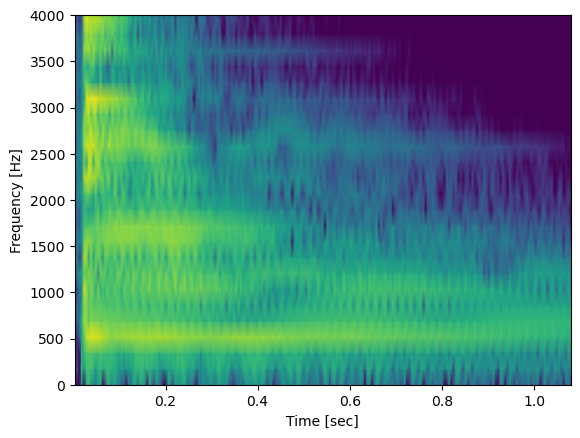

In [ ]:
from scipy.signal import spectrogram

# compute the spectrogram of the reference signal
ff, tt, S = spectrogram(ref, fs)


plot_spectrogram(ff, tt, S)
plt.ylim([0, 4000])  

1.2. Select a time where almost all harmonics are present and plot the spectrum at that time.

In [60]:
# Write the code here
plot_spectrum_at(ff, tt, S, 0.25)

1.3. Use the cursor for measuring the weights of the fundamental frequency and some harmonics (6-10)

In [84]:
weights = [1, 0.803, 0.408, 0.313, 0.089, 0.065] # Fill this list with the measured weights

**2. Synthesis**:

Let's define a function to synthetize an harmonic singal which receives the fundamental frequency ($f_0$) and the weights ($A_k$) of each harmonic and the time vector ($t$). This is similar to what you did in Lab 3- Ex3.2.


In [13]:
def synthesize(f0, phi, Ak, t):
  y = 0
  for k in range(1, len(Ak) + 1):
    y += Ak[k-1] * np.cos(2*np.pi*k*f0*t + k*phi - (k-1)*np.pi/2)
  return y

2.1. Use the `synthetize` function to generate a synthesis with the weights ($A_k$) found in 1.3 and the fundamental frequency and phases found in previous labs. Plot both the reference and the synthetize signal. Listen to the synthetize signal.

In [87]:
# Write the code here
duration = 1.0
f0 = 248
phi = 3 * np.pi/2
Ak = weights
t = np.arange(0, duration, 1/fs)
t_start = 0.335
t_end = 0.358

# generate the harmonic synthesized signal
synth = synthesize(f0, phi, Ak, t)

synth = 0.1 * synth / np.max(np.abs(synth)) # we normalize the amplitude to a maximum value of 0.1

plot_signals(ref, fs, t_start, t_end)
plot_signals(synth, fs, t_start, t_end)

2.2. Calculate the spectrogram of the synthesized signal `S_synt`; and compare the spectrums of both signals at the same time using `plot_spectrum_at(ff, tt, [S_ref, S_synt], time)`, where `S_ref`is spectrogram of the reference signal.

**Note:** use the same window length to calculate both spectrograms.

In [100]:
# Write the code here
ff, tt, S = spectrogram(ref, fs)
ff_synth, tt_synth, S_synth = spectrogram(synth, fs)
time = 0.5

plot_spectrum_at(ff, tt, [S, S_synth], time)

2.3. Compare the spectrograms of the two signals. What are the main differences?

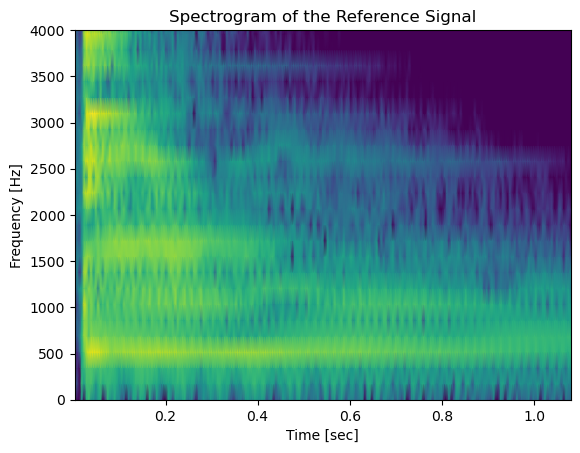

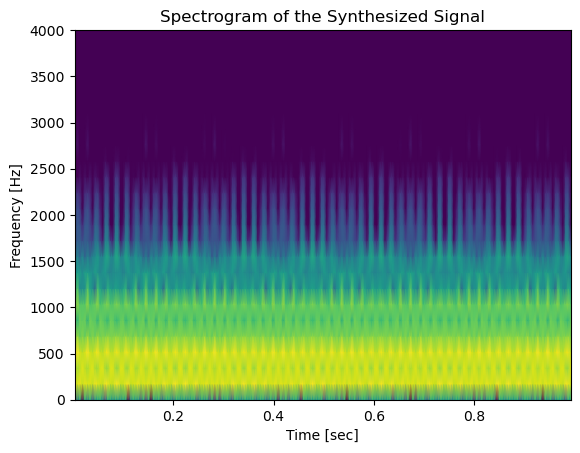

In [ ]:
# plot the spectrogram of the reference signal
plot_spectrogram(ff, tt, S)
plt.title("Spectrogram of the Reference Signal")
plt.ylim([0, 4000])
plt.show()

# plot the spectrogram of the synthesized signal
plot_spectrogram(ff_synth, tt_synth, S_synth)
plt.title("Spectrogram of the Synthesized Signal")
plt.ylim([0, 4000])
plt.show()


In the spectrogram of the reference signal, we can see a more complex structure with multiple frequency components and variations in amplitude over time. The harmonics are not perfectly stable, and there is additional spectral energy and noise between them. This indicates that the original recording includes natural characteristics such as timbral richness, background noise, and small fluctuations in pitch and intensity.
In contrast, the synthesized signal shows only a few clear and constant horizontal lines that correspond to the harmonic frequencies of the fundamental tone. These lines are very stable and clean, without noise or modulation, which is expected from a purely harmonic artificial signal.

2.4. Listen to the two audios (reference and synthesized). What are the main differences?

In [106]:
# Write the code here
from IPython.display import Audio
Audio(ref, rate=fs)


In [107]:
Audio(synth, rate=fs)

When listening to the two audios, the reference signal sounds more natural, rich, and realistic. It contains subtle variations in amplitude, pitch, and timbre that make it closer to a real instrument or human sound.
On the other hand, the synthesized signal sounds much more artificial and pure. It consists only of a few harmonic frequencies, without noise or temporal variations. As a result, it has a cleaner but flatter tone, similar to an electronic or computer-generated sound.